# Plot the feedbacks in single model abrupt Solar change experiments by using the radiative kernel 

## Reference: 50 year running mean

## GFDL model version

Original code written by Chenggong Wang 
> Available on [Github](https://github.com/ChenggongWang/Radiative_Response_with_Radiative_Kernel)

Modified by Maya V. Chung Jan 7 2025

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import subprocess 
import time
from scipy import stats
sstart_time0 = time.time()
import netCDF4

In [2]:
exp = '-6%solar'

FLOR_files = f'./rk_decomp_cloud/rk.decomp.FLOR.{exp}.50yrref.*.nc'
FLOR_rk = xr.open_mfdataset(FLOR_files, combine="by_coords", parallel=False)

CM21_files = f'./rk_decomp_cloud/rk.decomp.CM2.1p1.{exp}.50yrref.*.nc'
CM21_rk = xr.open_mfdataset(CM21_files, combine="by_coords", parallel=False)


# Plot Results (decomposed radiative response) in time series

In [3]:
# rh decomposition
def rh_decomposition(ds_rk):
    dR_temp_gm = (ds_rk['dR_Ta_rh_lw_gm'] + ds_rk['dR_Ta_rh_sw_gm'] + ds_rk['dR_ts_gm']).groupby('time.year').mean('time')
    dR_lr_gm   = (ds_rk['dR_LR_rh_lw_gm'] + ds_rk['dR_LR_rh_sw_gm']  ).groupby('time.year').mean('time')
    dR_clou_gm = (ds_rk['dR_cloud_lw_gm']  + ds_rk['dR_cloud_sw_gm'] ).groupby('time.year').mean('time')
    dR_wv_gm   = (ds_rk['dR_rh_lw_gm']     + ds_rk['dR_rh_sw_gm']    ).groupby('time.year').mean('time')
    dR_albe_gm = ds_rk['dR_alb_gm'].groupby('time.year').mean('time')
    dts_gm     = ds_rk['dts_gm']   .groupby('time.year').mean('time')
    
    return dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm

def conventional_decomposition(ds_rk):
    dR_temp_gm = (ds_rk['dR_ta_gm']        + ds_rk['dR_ts_gm']       ).groupby('time.year').mean('time')
    dR_lr_gm   = ds_rk['dR_lr_gm'].groupby('time.year').mean('time')
    dR_clou_gm = (ds_rk['dR_cloud_lw_gm']  + ds_rk['dR_cloud_sw_gm'] ).groupby('time.year').mean('time')
    dR_wv_gm   = (ds_rk['dR_wv_lw_gm']     + ds_rk['dR_wv_sw_gm']    ).groupby('time.year').mean('time')
    dR_albe_gm = ds_rk['dR_alb_gm'].groupby('time.year').mean('time')
    dts_gm     = ds_rk['dts_gm']   .groupby('time.year').mean('time')
    
    return dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm

def plot_decomposition(ds_rk, ax1, decomp_type='rh'):
    if decomp_type == 'rh':
        dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm = rh_decomposition(ds_rk)
    elif decomp_type == 'conventional':
        dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm = conventional_decomposition(ds_rk)
    
    ax1.plot(dts_gm,dR_temp_gm/5,'.',label='dR_Temp/5')
    ax1.plot(dts_gm,dR_clou_gm,'.',label='dR_Cloud')
    ax1.plot(dts_gm,dR_albe_gm,'.',label='dR_Albe')
    if decomp_type == 'rh':
        ax1.plot(dts_gm,dR_wv_gm,'.',label='dR_RH')
    elif decomp_type == 'conventional':
        ax1.plot(dts_gm,dR_wv_gm,'.',label='dR_WV')
    ax1.set_xlabel('dTs')
    ax1.axhline(0,color='k',linewidth=1,zorder=0)
    ax1.grid(linestyle='--')

# Plot functions

In [4]:
# plot full timeseries
def plot_feedbacks_ts(FLOR_rk, CM21_rk, exp):

    # RH decomposition
    fig, ax = plt.subplots(1,2,figsize=(10,5),dpi=150, constrained_layout=True,sharex=True,sharey=True)
    
    plot_decomposition(FLOR_rk,ax[0],decomp_type='rh')
    ax[0].set_title(f'FLOR')
    ax[0].legend()
    
    plot_decomposition(CM21_rk,ax[1],decomp_type='rh')
    ax[1].set_title(f'CM2.1')
    ax[1].legend()
    
    fig.suptitle(f'Feedbacks (RH decomposition): {exp}% Solar')
    
    
    # conventional decomposition
    fig, ax = plt.subplots(1,2,figsize=(10,5),dpi=150, constrained_layout=True,sharex=True,sharey=True)
    
    plot_decomposition(FLOR_rk,ax[0],decomp_type='conventional')
    ax[0].set_title(f'FLOR')
    ax[0].legend()
    
    plot_decomposition(CM21_rk,ax[1],decomp_type='conventional')
    ax[1].set_title(f'CM2.1')
    ax[1].legend()
    
    fig.suptitle(f'Feedbacks (conventional decomposition): {exp}% Solar')

In [5]:
# calculate climate feedbacks
def calc_feedbacks(dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm, 
                   decomp_type='rh', print_output=False):
    
    # regress the RR on to ts and the slope is the climate feedback
    if decomp_type == 'conventional':
        fb_name = ['Planck','LR','Cloud','WV','Albedo']
        dR_list = {
        'Planck':dR_temp_gm-dR_lr_gm,
        'LR':dR_lr_gm,
        'Cloud': dR_clou_gm,
        'WV':dR_wv_gm,
        'Albedo':dR_albe_gm
        }
    if decomp_type == 'rh':
        fb_name = ['Planck','LR','Cloud','RH','Albedo']
        dR_list = {
        'Planck':dR_temp_gm-dR_lr_gm,
        'LR':dR_lr_gm,
        'Cloud': dR_clou_gm,
        'RH':dR_wv_gm,
        'Albedo':dR_albe_gm
        }
    if 'albedo' in decomp_type:
        fb_name = ['Albedo','Non-Albedo']
        dR_list = {
        'Albedo':dR_albe_gm,
        'Non-Albedo':dR_temp_gm+dR_clou_gm+dR_wv_gm #-dR_lr_gm+dR_lr_gm
        }
    
    slope_list = []
    for name in fb_name:

        fb = stats.linregress(dts_gm, dR_list[name]).slope
        if print_output == True:
            print(f'{name:6s}:{fb:5.2f} W/m2/K')
        
        my_dict = {f'{name:6s}': fb}
        slope_list.append(my_dict)
        
    return slope_list
        
def decomp_calc_feedbacks(ds_rk, decomp_type='rh',print_output=False):
    if decomp_type not in ['conventional','rh','albedo']:
        print('Error: please input valid decomposition type: conventional, rh, albedo')
    
    if decomp_type == 'conventional':
        dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm = conventional_decomposition(ds_rk)
    
    elif decomp_type == 'rh':
        dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm = rh_decomposition(ds_rk)
    
    elif 'albedo' in decomp_type: # use the conventional decomposition
        dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm = rh_decomposition(ds_rk)
    
    slope_list = calc_feedbacks(dR_temp_gm, dR_lr_gm, dR_clou_gm, dR_wv_gm, dR_albe_gm, dts_gm,
                               decomp_type, print_output)
    
    return slope_list

In [6]:
import matplotlib.colors as mcolors

def plot_multiple_datasets(ax,data_list, cmap='Blues', dataset_names=['FLOR','CM2.1'], 
                           title='', legendtitle=''):
    """
    Plots multiple datasets as bar plots side by side, with bars colored based on words,
    different shadings for each dataset, and a black outline around each bar.

    Parameters:
    - data_list: List of datasets (each dataset is a list of dictionaries).
    - dataset_names: A list of names for each dataset to use in the legend.
    """
    
    if len(data_list) != len(dataset_names):
        raise ValueError("Length of data_list and dataset_names must be the same")

    num_datasets = len(data_list)
    bar_width = 0.1  # Width of each bar
    indices = np.arange(len(data_list[0]))  # Positions for the bars

    # Generate different shadings for each dataset
    colormap = plt.get_cmap(cmap)
    shadings = [colormap(i / num_datasets) for i in range(num_datasets)]

    # Iterate through datasets and plot each
    for i, data in enumerate(data_list):
        # Extract names and values for each dataset
        names = [list(item.keys())[0].strip() for item in data]  # Get the names
        values = [list(item.values())[0] for item in data]  # Get the values
        
        # Plot each dataset with an offset for the bars
        values_neg = [-1 * i for i in values]
        ax.bar(indices + i * bar_width, values_neg, bar_width, label=dataset_names[i], color=shadings[i], edgecolor='black')
        # did negative value to keep with the alpha feedback framework (positive = stable)

    # Customize the plot
    ax.set_xlabel('Feedback')
    ax.set_ylabel('W/m2/K')
    ax.set_title(title)
    ax.set_xticks(indices + bar_width * (num_datasets - 1) / 2)
    ax.set_xticklabels(names)
    ax.legend(title=legendtitle)
    ax.axhline(0,color='k',linewidth=1)
    ax.grid(linestyle='--')


In [7]:
# make empty datasets to normalize the colors between the subplots

empty_data_conventional = [{'Planck ': 0},
 {'LR    ': 0},
 {'Cloud ': 0},
 {'WV    ': 0},
 {'Albedo   ': 0}]

empty_data_rh = [{'Planck ': 0},
 {'LR    ': 0},
 {'Cloud ': 0},
 {'RH    ': 0},
 {'Albedo   ': 0}]

empty_data_albedo = [{'Albedo ': 0},
 {'Non-Albedo    ': 0}]

In [8]:
def barplot_feedbacks_overtime_m6(FLOR_rk, CM21_rk, decomp_type='rh', exp='-6'):
    import matplotlib.pyplot as plt

    if decomp_type == 'albedo':
        figsize = (8, 8)
        empty = empty_data_albedo
    elif decomp_type == 'rh':
        figsize = (12, 5)
        empty = empty_data_rh
    else:
        figsize = (12, 5)
        empty = empty_data_conventional

    fig, ax = plt.subplots(1, 2, figsize=figsize, dpi=120, sharex=True, sharey=True)

    # === FLOR ===
    dataset_names_FLOR = ['21-100', '101-300', '301-400', '401-497', '', '']
    f2 = decomp_calc_feedbacks(FLOR_rk.isel(time=slice(21 * 12, 100 * 12)), decomp_type=decomp_type)
    f3 = decomp_calc_feedbacks(FLOR_rk.isel(time=slice(101 * 12, 300 * 12)), decomp_type=decomp_type)
    f4 = decomp_calc_feedbacks(FLOR_rk.isel(time=slice(301 * 12, 400 * 12)), decomp_type=decomp_type)
    f5 = decomp_calc_feedbacks(FLOR_rk.isel(time=slice(401 * 12, 497 * 12)), decomp_type=decomp_type)
    f6 = empty
    f7 = empty

    plot_multiple_datasets(
        ax[0], [f2, f3, f4, f5, f6, f7],
        cmap='Blues_r',
        dataset_names=dataset_names_FLOR,
        title='FLOR',
        legendtitle='Years'
    )

    # === CM2.1 ===
    dataset_names_CM21 = ['21-100', '101-300', '301-400', '401-500', '501-750', '751-900', '901-1193']
    f2 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(21 * 12, 100 * 12)), decomp_type=decomp_type)
    f3 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(101 * 12, 300 * 12)), decomp_type=decomp_type)
    f4 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(301 * 12, 400 * 12)), decomp_type=decomp_type)
    f5 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(401 * 12, 500 * 12)), decomp_type=decomp_type)
    f6 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(501 * 12, 750 * 12)), decomp_type=decomp_type)
    f7 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(751 * 12, 900 * 12)), decomp_type=decomp_type)
    f8 = decomp_calc_feedbacks(CM21_rk.isel(time=slice(900 * 12, 1193 * 12)), decomp_type=decomp_type)

    plot_multiple_datasets(
        ax[1], [f2, f3, f4, f5, f6, f7, f8],
        cmap='Blues_r',
        dataset_names=dataset_names_CM21,
        title='CM2.1',
        legendtitle='Years'
    )

    fig.suptitle(f'Feedbacks for {exp}% Solar over time\n({decomp_type} decomposition)')
    ax[1].set_ylabel('')
    ax[1].legend(title='Years', loc='upper right')

    return fig


# Plot

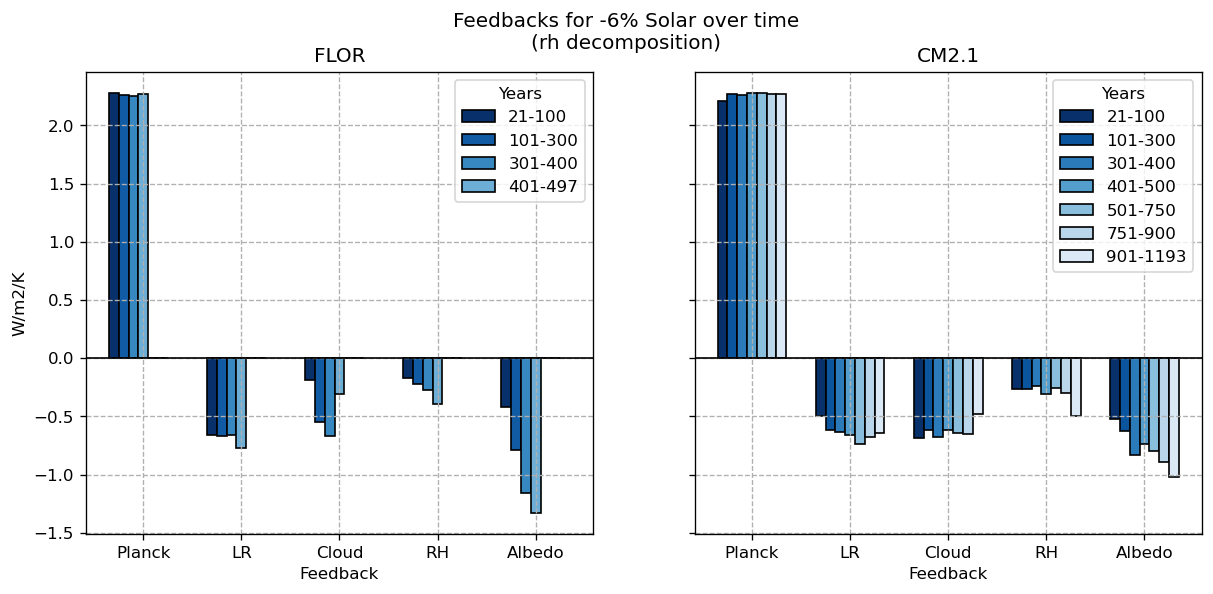

In [9]:
# plot with RH decomposition
fig = barplot_feedbacks_overtime_m6(FLOR_rk, CM21_rk, decomp_type = 'rh', exp='-6')

In [10]:
# save figure for paper
fig.savefig("FigureS2.pdf")

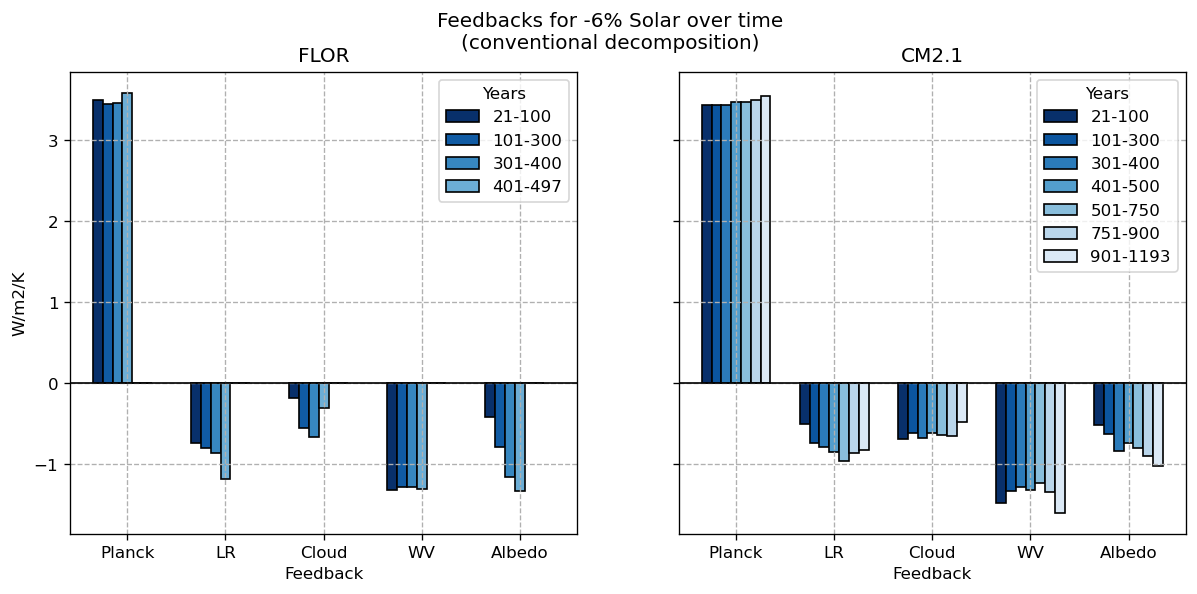

In [26]:
# plot conventional decomposition
fig2 = barplot_feedbacks_overtime_m6(FLOR_rk, CM21_rk, decomp_type = 'conventional', exp='-6')

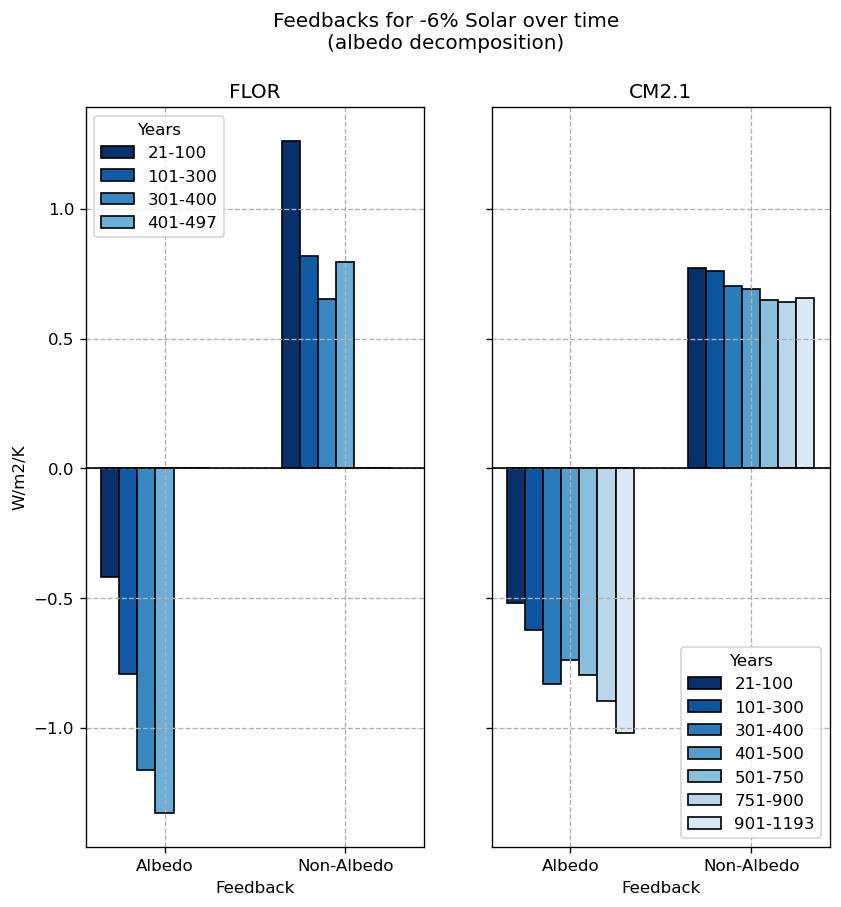

In [22]:
# plot albedo and non-albedo feedbacks
fig_albedo = barplot_feedbacks_overtime_m6(FLOR_rk, CM21_rk, decomp_type = 'albedo', exp='-6')

In [15]:
def barplot_feedbacks_overtime(FLOR_rk, CM21_rk, decomp_type='rh', exp='-6', interval_years=200):
    import matplotlib.pyplot as plt
    import numpy as np

    # Determine which "empty" structure to use
    if decomp_type == 'albedo':
        figsize = (8, 8)
        empty = empty_data_albedo
    elif decomp_type == 'rh':
        figsize = (12, 5)
        empty = empty_data_rh
    else:
        figsize = (12, 5)
        empty = empty_data_conventional

    fig, ax = plt.subplots(1, 2, figsize=figsize, dpi=120, sharex=True, sharey=True)

    def get_time_blocks(ds, start_year=21, interval=interval_years):
        """
        Split the dataset into time intervals (in years), starting from `start_year`.
        Returns list of (start_index, end_index, label) for each interval.
        """
        time_in_years = ds.time.size // 12
        blocks = []
        current = start_year
        while current < time_in_years:
            start_idx = current * 12
            end_year = min(current + interval, time_in_years)
            end_idx = end_year * 12
            label = f"{current}-{end_year}"
            blocks.append((start_idx, end_idx, label))
            current += interval
        return blocks

    def process_model(ds, axis, title):
        blocks = get_time_blocks(ds)
        data_list = []
        labels = []

        for start, end, label in blocks:
            if end > ds.time.size:
                break
            fb = decomp_calc_feedbacks(ds.isel(time=slice(start, end)), decomp_type=decomp_type)
            data_list.append(fb)
            labels.append(label)

        # Pad with empty to keep layout consistent (up to 7 bars)
        while len(data_list) < 7:
            data_list.append(empty)
            labels.append("")

        plot_multiple_datasets(
            axis,
            data_list,
            cmap='Blues_r',
            dataset_names=labels,
            title=title,
            legendtitle='Years'
        )

    process_model(FLOR_rk, ax[0], 'FLOR')
    process_model(CM21_rk, ax[1], 'CM2.1')

    fig.suptitle(f'Feedbacks for {exp}% Solar over time\n({decomp_type} decomposition)')
    ax[1].set_ylabel('')
    ax[1].legend(title='Years', loc='upper right')

    plt.show()
    
    return fig


# main section (import data and plot)

plotting...


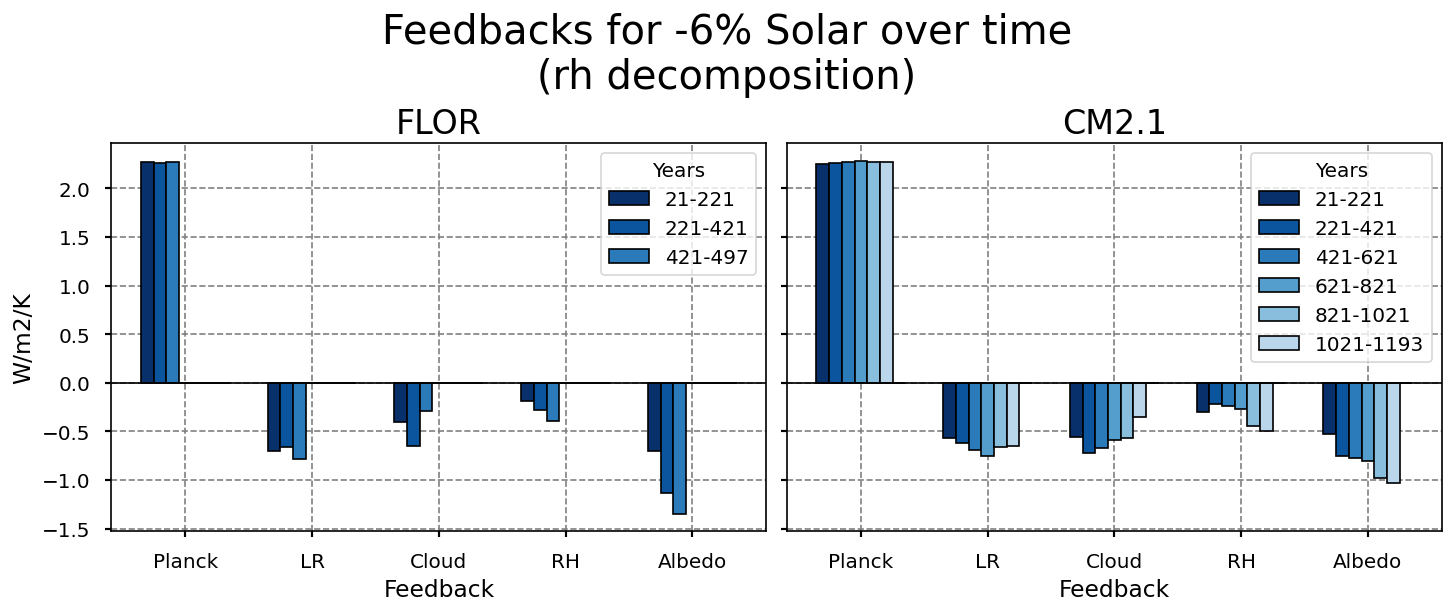

plotting...


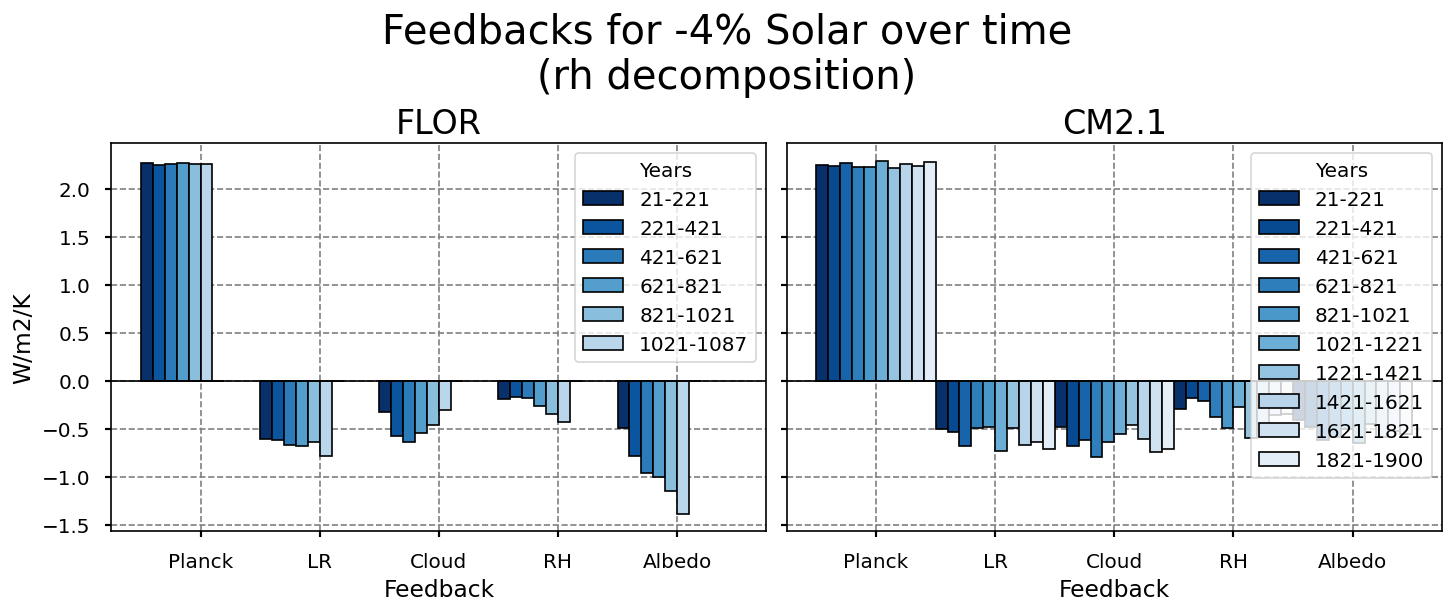

plotting...


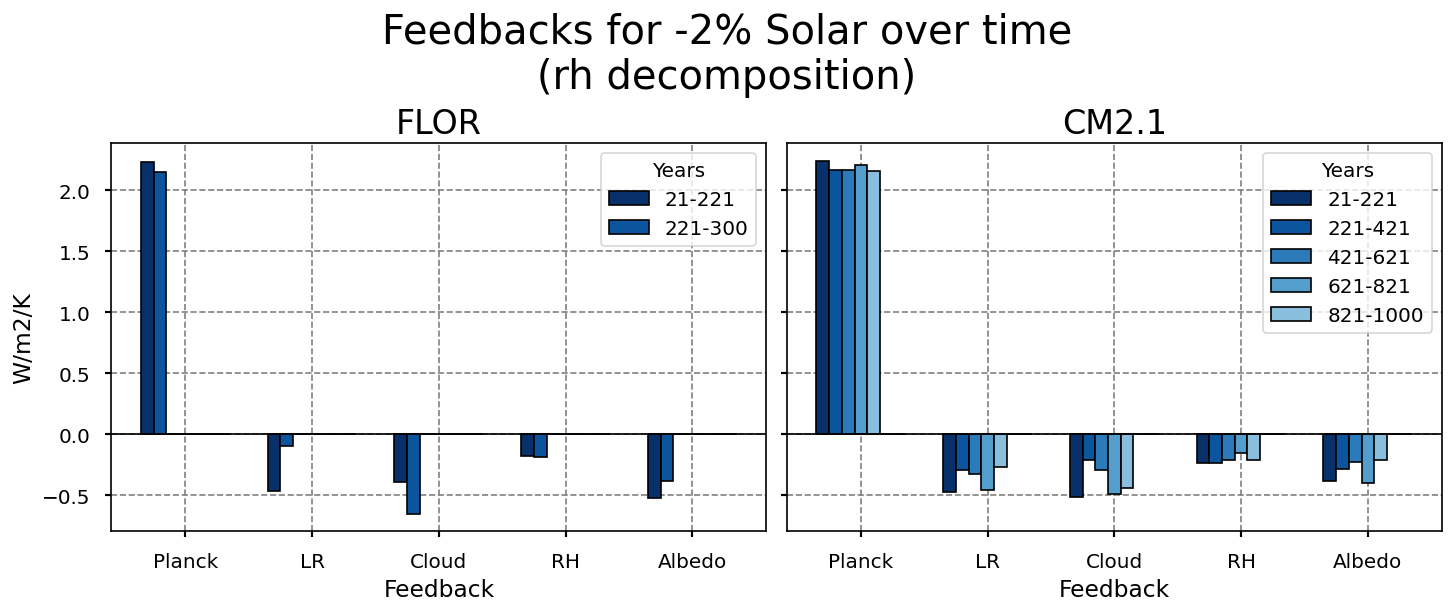

plotting...


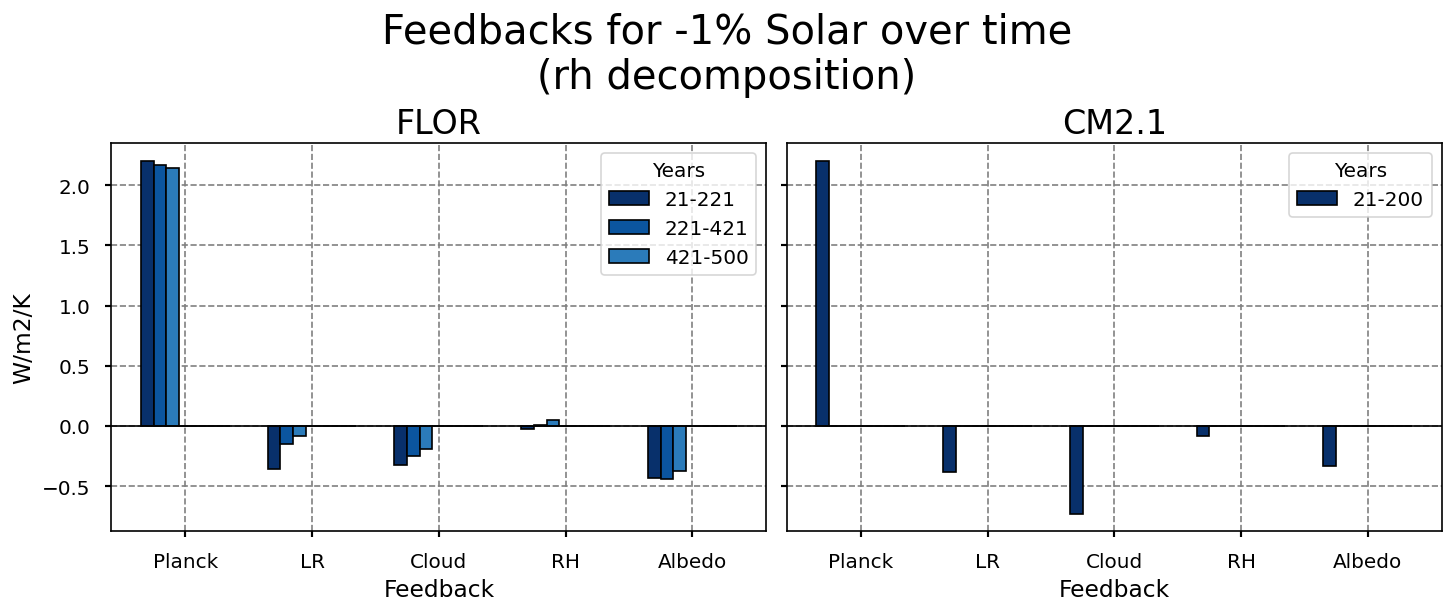

plotting...


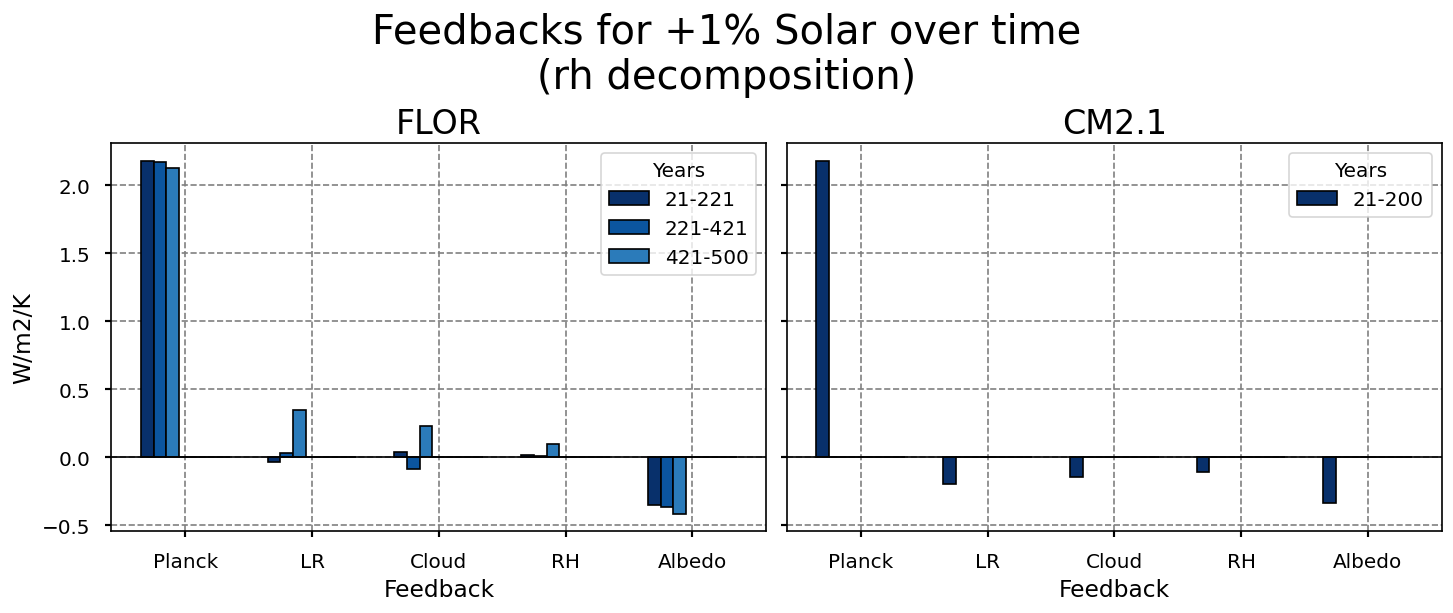

plotting...


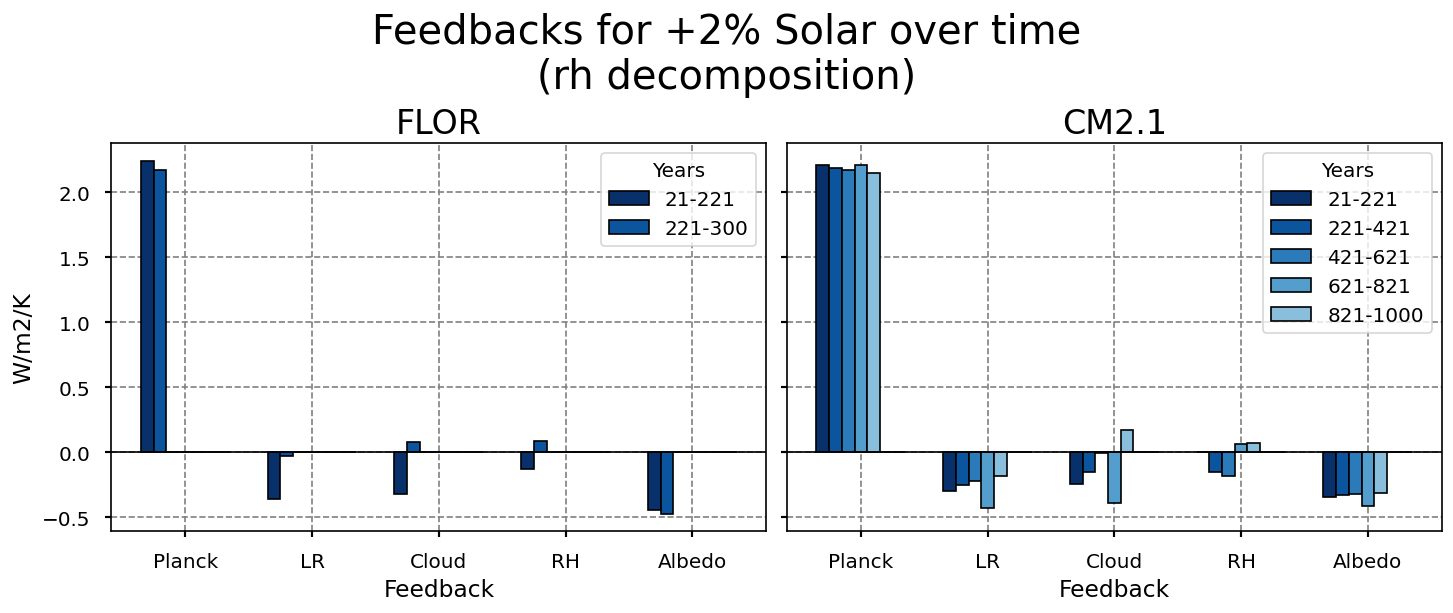

plotting...


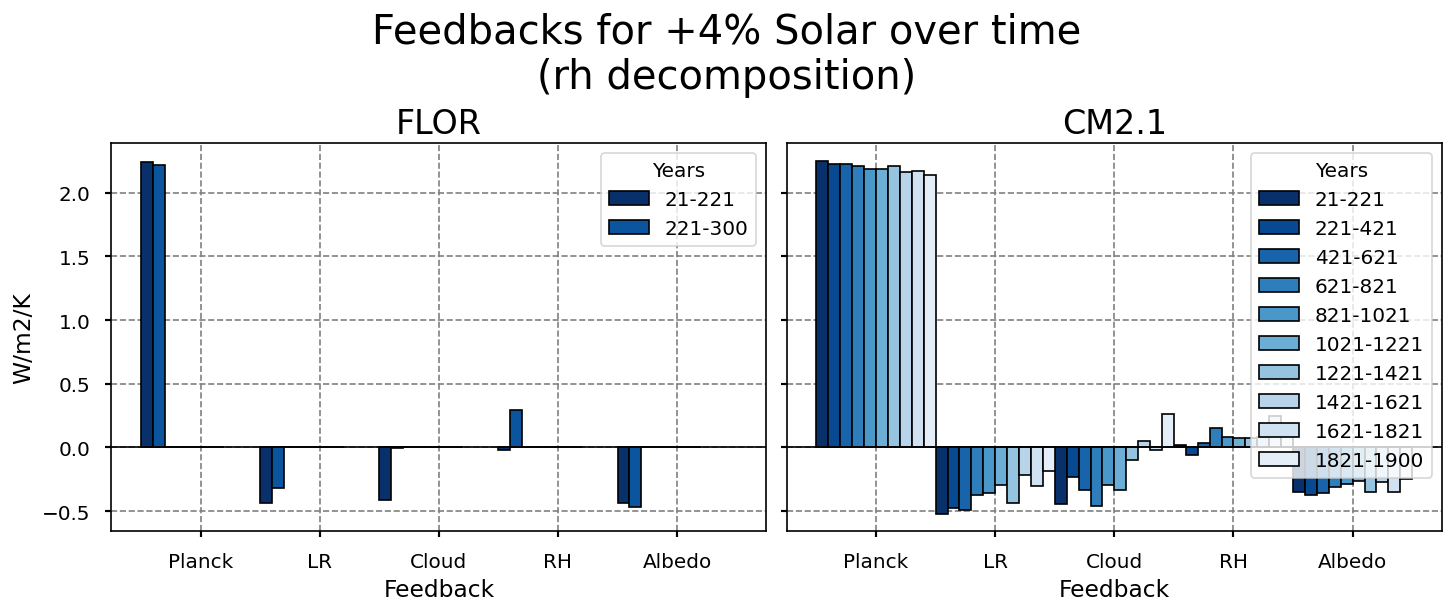

plotting...


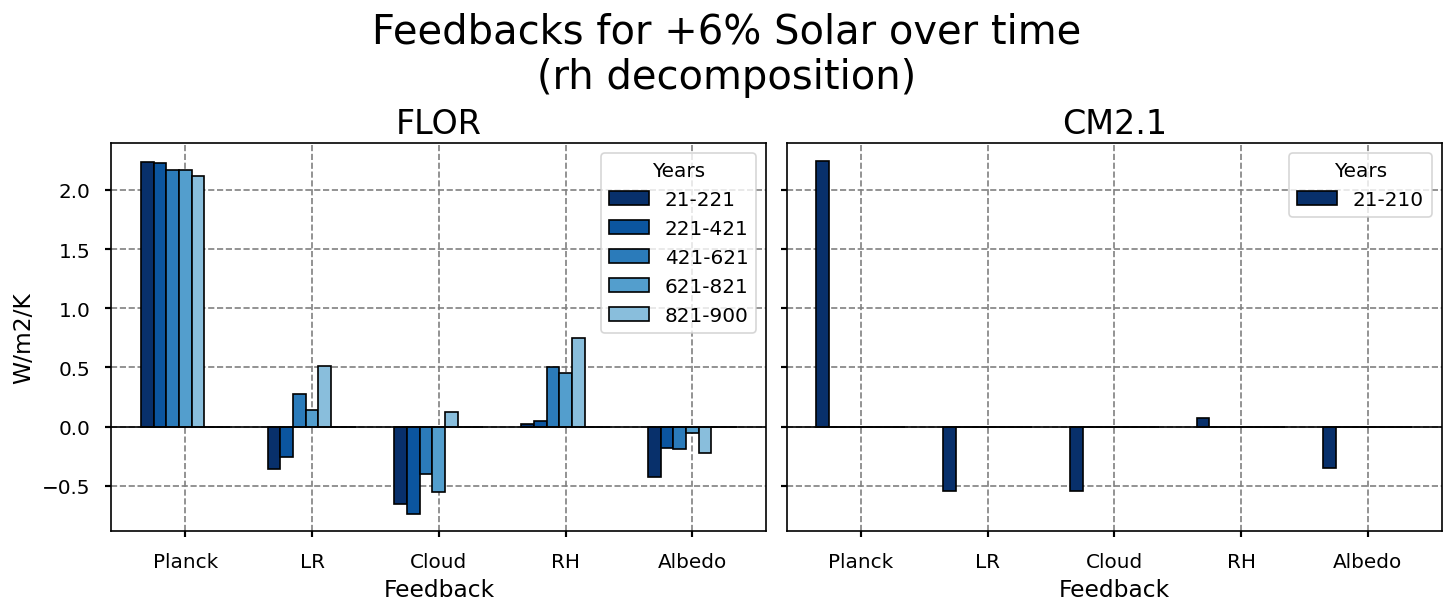

In [16]:
# plot style
plt.style.use('/tigress/mvchung/ANALYSIS/func/paper.mplstyle')

# import data

experiments = ['-6','-4','-2','-1','+1','+2','+4','+6']

for exp in experiments:

    FLOR_files = f'./rk_decomp_cloud/rk.decomp.FLOR.{exp}%solar.50yrref.*.nc'
    FLOR_rk = xr.open_mfdataset(FLOR_files, combine="by_coords", parallel=False)
    
    CM21_files = f'./rk_decomp_cloud/rk.decomp.CM2.1p1.{exp}%solar.50yrref.*.nc'
    CM21_rk = xr.open_mfdataset(CM21_files, combine="by_coords", parallel=False)

    # timeseries plots
    #plot_feedbacks_ts(FLOR_rk, CM21_rk, exp)
    
    print('plotting...')
    fig = barplot_feedbacks_overtime(FLOR_rk, CM21_rk, decomp_type = 'rh', exp = exp)
    #fig = barplot_feedbacks_overtime(FLOR_rk, CM21_rk, decomp_type = 'conventional', exp = exp)
    #fig = barplot_feedbacks_overtime(FLOR_rk, CM21_rk, decomp_type = 'albedo', exp = exp)
    

# Look at residuals for all experiments

In [17]:
from Radiative_Response_with_Radiative_kernel_cloud import global_mean_xarray

def get_resid(ds_rk):
    
    dR_resid_gm = global_mean_xarray(ds_rk['dR_resid_lw'] + ds_rk['dR_resid_sw']).astype('float32')
    dR_resid_gm = dR_resid_gm.groupby('time.year').mean('time')
    
    dts_gm     = ds_rk['dts_gm']   .groupby('time.year').mean('time')
    
    return dR_resid_gm, dts_gm

def calc_resid_feedback(dR_resid_gm, dts_gm, print_output=False):
    
    # regress the RR on to ts and the slope is the climate feedback
    fb_name = ['Resid']
    dR_list = {'Resid':dR_resid_gm}
    
    slope_list = []
    for name in fb_name:

        fb = stats.linregress(dts_gm, dR_list[name]).slope    # do the linear regression with surface temperature change, feedback = slope
        if print_output == True:
            print(f'{name:6s}:{fb:5.2f} W/m2/K')
        
        my_dict = {f'{name:6s}': fb}
        slope_list.append(my_dict)
        
    return slope_list[0]



Loading results from resid_feedback_results.nc


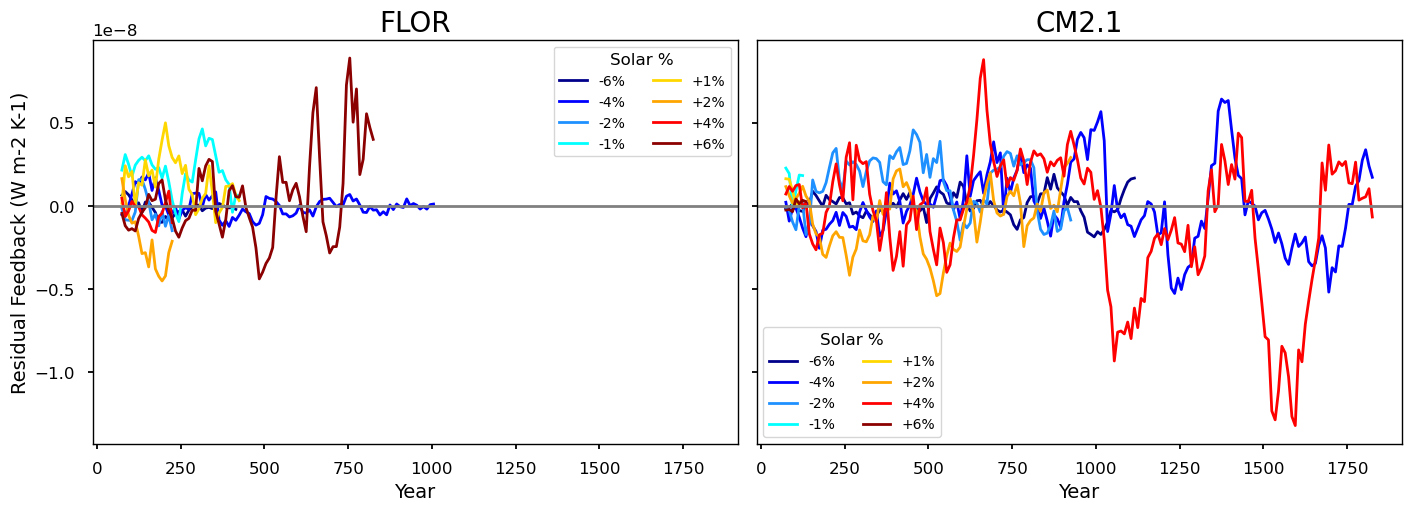

In [20]:
import glob
import os

window_len = 150
step = 10

experiments = ['-6', '-4', '-2', '-1', '+1', '+2', '+4', '+6']
models = ['FLOR', 'CM2.1p1']
colors = ['darkblue', 'blue', 'dodgerblue', 'cyan', 'gold', 'orange', 'red', 'darkred']

fileo = "resid_feedback_results.nc"

if os.path.exists(fileo) == 1:
    print(f"Loading results from {fileo}")
    da = xr.load_dataarray(fileo)

else:
    # Create placeholders for longest possible time dimension
    max_years = 0
    for exp in experiments:
        for model in models:
            files = f'./rk_decomp_cloud/rk.decomp.{model}.{"p1." if model=="CM2.1" else ""}{exp}%solar.50yrref.*.nc'
            if glob.glob(files):
                ds = xr.open_mfdataset(files, combine="by_coords", parallel=False)
                dR_resid, dts_gm = get_resid(ds)
                total_years = dR_resid.year.size
                max_years = max(max_years, total_years - window_len + 1)

    da = xr.DataArray(
        np.full((len(models), len(experiments), max_years), np.nan),
        dims=["model", "experiment", "time_index"],
        coords={"model": models, "experiment": experiments, "time_index": np.arange(max_years)},
        name="residual_feedback"
    )

    # Fill the DataArray
    for exp in experiments:
        for model in models:
            files = f'./rk_decomp_cloud/rk.decomp.{model}.{"p1." if model=="CM2.1" else ""}{exp}%solar.50yrref.*.nc'
            if not glob.glob(files):
                print(f"No files for {model} {exp}% — skipping.")
                continue

            try:
                ds = xr.open_mfdataset(files, combine="by_coords", parallel=False)
                dR_resid, dts_gm = get_resid(ds)
                total_years = dR_resid.year.size

                feedbacks = []
                for start in range(0, total_years - window_len + 1, step):
                    end = start + window_len
                    fb = calc_resid_feedback(
                        dR_resid.isel(year=slice(start, end)),
                        dts_gm.isel(year=slice(start, end))
                    )
                    feedbacks.append(fb['Resid '])

                da.loc[dict(model=model, experiment=exp, time_index=np.arange(len(feedbacks)))] = feedbacks

            except Exception as e:
                print(f"Error processing {model} {exp}%: {e}")

    # Save to NetCDF
    da.to_netcdf(fileo)
    print(f"Saved results to {fileo}")

# === Plotting ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

for exp, color in zip(experiments, colors):
    # FLOR
    if exp in da.sel(model="FLOR").experiment.values:
        vals = da.sel(model="FLOR", experiment=exp).dropna("time_index")
        ax1.plot(vals["time_index"]*step + window_len/2, vals, label=f"{exp}%", color=color)

    # CM2.1
    if exp in da.sel(model="CM2.1p1").experiment.values:
        vals = da.sel(model="CM2.1p1", experiment=exp).dropna("time_index")
        ax2.plot(vals["time_index"]*step + window_len/2, vals, label=f"{exp}%", color=color)

ax1.set_title('FLOR')
ax2.set_title('CM2.1')
ax1.set_xlabel('Year')
ax2.set_xlabel('Year')
ax1.set_ylabel('Residual Feedback (W m-2 K-1)')

ax1.legend(title='Solar %', ncol=2, fontsize='small')
ax2.legend(title='Solar %', ncol=2, fontsize='small')

ax1.axhline(0, color='gray')
ax2.axhline(0, color='gray')
